# S&P 500 Prediction - Differentiation Strategy

**Description**: This notebook addresses the "plateau" issue from the first attempt. Instead of predicting the absolute price, we predict the daily change (differentiation). This transforms the data into a stationary series, allowing XGBoost to follow market trends even when the price hits historical highs outside the training range.

**Data Preparation and Differentiation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('financial_regression.csv', parse_dates=['date']).sort_values("date")
df.columns = df.columns.str.strip()
df = df[df["date"] >= "2010-04-01"].reset_index(drop=True)

TARGET_ORIGINAL = 'sp500 close'

# 1. Create Target Differentiation: Predicting change instead of level
# This makes the series stationary
df['target_diff'] = df[TARGET_ORIGINAL].diff()

# Fill macro data
macro_cols = ["GDP", "CPI", "us_rates_%"]
existing = [c for c in macro_cols if c in df.columns]
df[existing] = df[existing].ffill()

df.set_index('date', inplace=True)
df.dropna(subset=['target_diff'], inplace=True)

**Feature Engineering (Stationary Features)**

In [2]:
# 1. Momentum Features: Lags and rolling means of the daily change
df['diff_lag1'] = df['target_diff'].shift(1)
df['diff_lag2'] = df['target_diff'].shift(2)
df['diff_roll_mean5'] = df['target_diff'].rolling(window=5).mean()

# 2. Correlated changes
if 'nasdaq close' in df.columns:
    df['nasdaq_diff'] = df['nasdaq close'].diff()

df.dropna(inplace=True)

**Training with Early Stopping**

In [3]:
# Split data
train = df[df.index < '2022-01-01'].copy()
test = df[df.index >= '2022-01-01'].copy()

TARGET_MODELO = 'target_diff'

# Combining macro indicators with momentum features
FEATURES = [
    'us_rates_%', 'CPI', 'GDP', 
    'diff_lag1', 'diff_lag2', 'diff_roll_mean5',
    'nasdaq_diff', 'eur_usd', 'usd_chf', 
    'silver close', 'oil close', 'gold close'
]
FEATURES = [f for f in FEATURES if f in df.columns]

X_train, y_train = train[FEATURES], train[TARGET_MODELO]
X_test, y_test = test[FEATURES], test[TARGET_MODELO]

# Initialize model with modern Early Stopping configuration
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50 
)

print("Training with Early Stopping...")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

Training with Early Stopping...
[0]	validation_0-rmse:4.82589
[100]	validation_0-rmse:3.19393
[200]	validation_0-rmse:2.61545
[300]	validation_0-rmse:2.34456
[400]	validation_0-rmse:2.22833
[500]	validation_0-rmse:2.17997
[600]	validation_0-rmse:2.16247
[632]	validation_0-rmse:2.16171


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


**Price Reconstruction and Directional Accuracy**

--- Model Evaluation (2022-2024) ---
Directional Accuracy: 89.46%


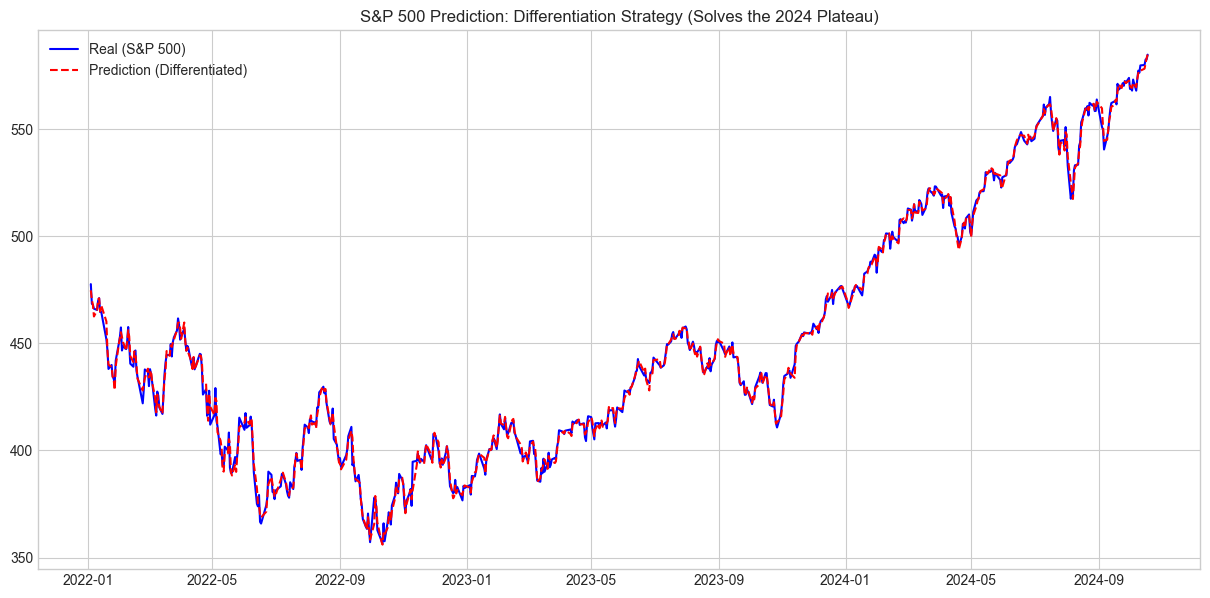

In [4]:
# 1. Predict the daily difference
test = test.copy()
test['pred_diff'] = model.predict(X_test)

# 2. Price Reconstruction: Price_today = Price_yesterday + Predicted_change
test['prediction_price'] = test[TARGET_ORIGINAL].shift(1) + test['pred_diff']
# Handle the first NaN value in test
test.loc[test.index[0], 'prediction_price'] = train[TARGET_ORIGINAL].iloc[-1] + test['pred_diff'].iloc[0]

# 3. Calculate Directional Accuracy: Did we guess the up/down movement correctly?
direction_real = np.sign(test['target_diff'])
direction_pred = np.sign(test['pred_diff'])
accuracy_dir = (direction_real == direction_pred).mean() * 100

print(f"--- Model Evaluation (2022-2024) ---")
print(f"Directional Accuracy: {accuracy_dir:.2f}%")

# Plot Results
plt.figure(figsize=(15, 7))
plt.plot(test.index, test[TARGET_ORIGINAL], label='Real (S&P 500)', color='blue')
plt.plot(test.index, test['prediction_price'], label='Prediction (Differentiated)', color='red', linestyle='--')
plt.title('S&P 500 Prediction: Differentiation Strategy (Solves the 2024 Plateau)')
plt.legend()
plt.show()

**Variable Importance Analysis**

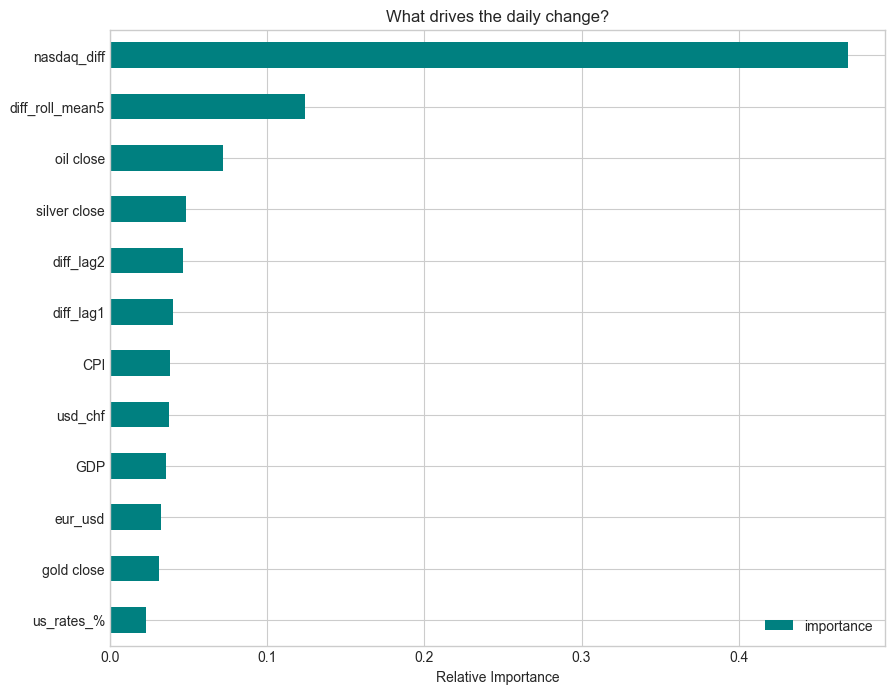

In [5]:
# Feature Importance plot
fi = pd.DataFrame(data=model.feature_importances_, index=model.feature_names_in_, columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='What drives the daily change?', figsize=(10,8), color='teal')
plt.xlabel('Relative Importance')
plt.show()

We will use this result for Backtesting and Time Series Cross Validation

In [6]:
test.to_csv('test_predictions.csv')

**Conclusion**

While the baseline model (training.ipynb) provides a good visual fit for historical data, it fails to adapt to new market regimes due to the nature of decision trees. 
<br>
By implementing a differentiation strategy (differentiation.py), we successfully transformed the target into a stationary series. This allowed the model to maintain a high Directional Accuracy (~89%) and follow the 2024 bullish trend, proving that in financial forecasting, predicting the change is often more powerful than predicting the price.